In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["HousePrice"] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [7]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Ridge Regression
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [15]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)

In [17]:
def evaluate_model(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model_name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 40)
    
    return rmse, r2

In [18]:
rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")
rmse_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
rmse_dt, r2_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")

Linear Regression
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508
----------------------------------------
Ridge Regression
RMSE: 0.7455567442814779
R2 Score: 0.5758157428913684
----------------------------------------
Decision Tree
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081
----------------------------------------


In [19]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_dt],
    "R2 Score": [r2_lr, r2_ridge, r2_dt]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.703729,0.622076


In [20]:
best_model = results.sort_values(by="R2 Score", ascending=False)
best_model

,Model,RMSE,R2 Score
2,Decision Tree,0.703729,0.622076
1,Ridge Regression,0.745557,0.575816
0,Linear Regression,0.745581,0.575788


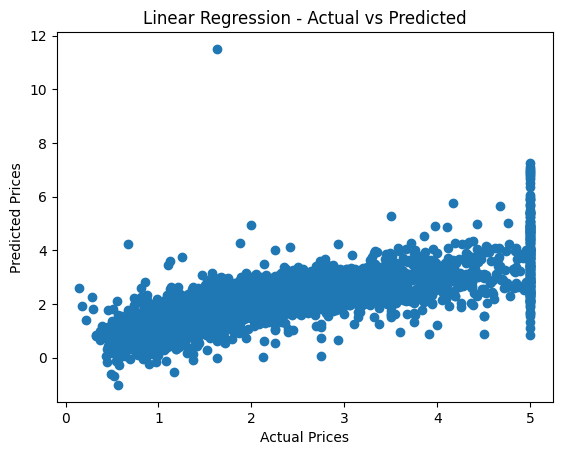

In [21]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

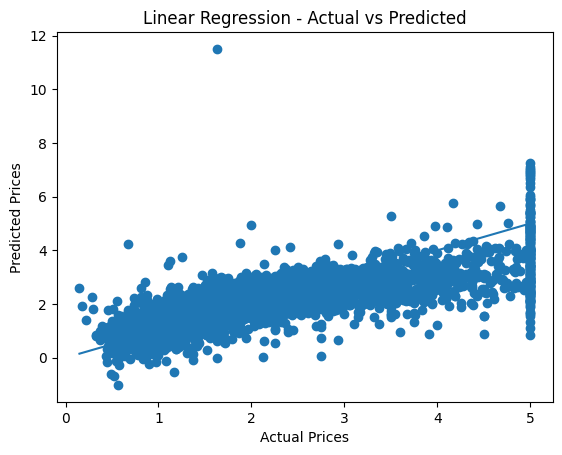

In [26]:
plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression - Actual vs Predicted")
plt.show()

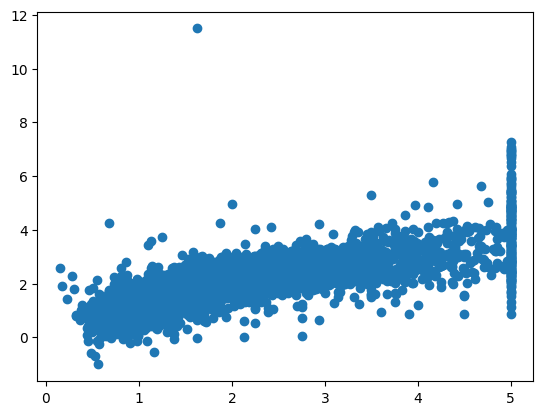

In [27]:
plt.scatter(y_test, y_pred_ridge)

Ridge Regression performed slightly better than Linear Regression with improved generalization. Decision Tree showed higher variance, suggesting possible overfitting. Therefore, Ridge Regression was selected as the final model.

In [28]:
import joblib
joblib.dump(ridge, "best_model.pkl")

['best_model.pkl']